In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    learning_curve
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# CREATE OUTPUT FOLDERS


os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)


# LOAD DATASET

df = pd.read_csv("/content/Iris (1).csv")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())
print("\nLast Five Rows:")
print(df.tail())
print("\nDuplicate Rows :", df.duplicated().sum())

print("\nClass Distribution")
print(df["Species"].value_counts())

# Drop ID column if present

if "Id" in df.columns:
    df.drop("Id", axis=1, inplace=True)

# DESCRIPTIVE STATISTICS

print("\nSummary Statistics")
print(df.describe())

# FEATURES AND LABELS


X = df.drop("Species", axis=1)

y = df["Species"]


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("\nTraining Samples :", len(X_train))

print("Testing Samples :", len(X_test))

print("\nData preprocessing completed.")


Dataset Shape:
(150, 6)

First Five Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4)


Generating Histograms...


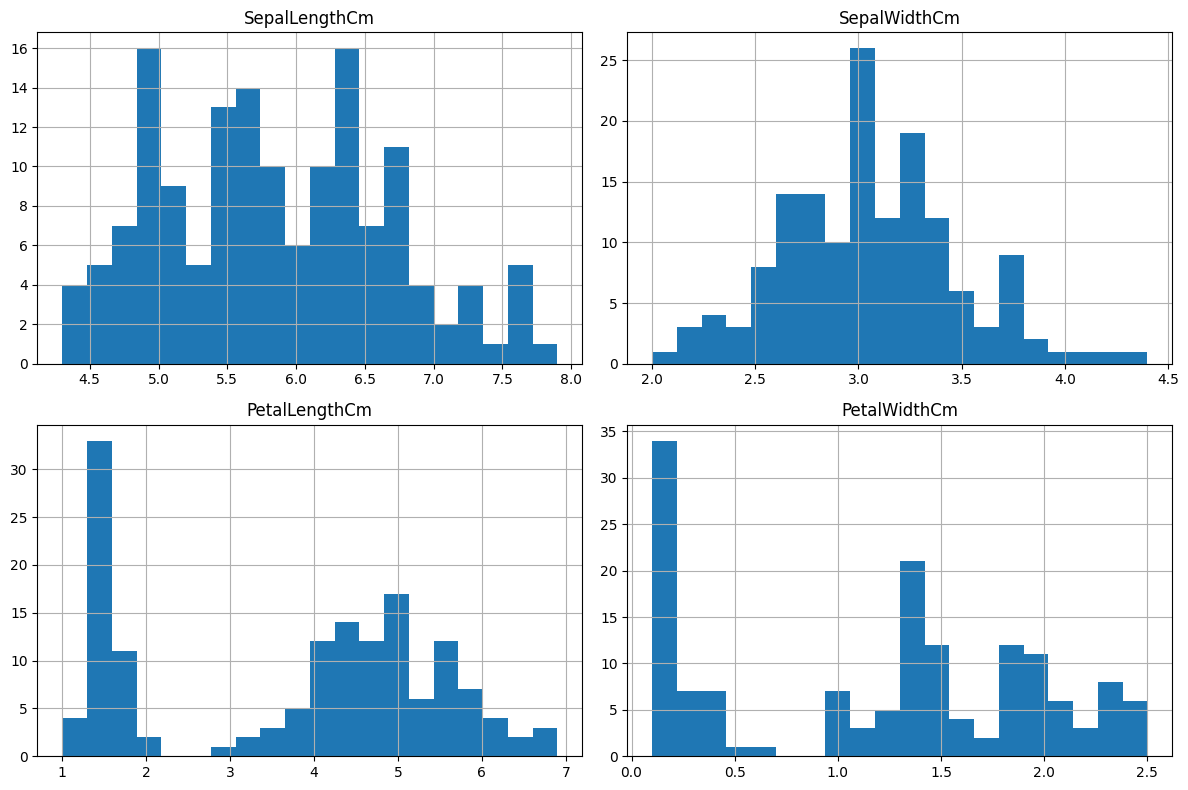

In [ ]:
# HISTOGRAMS

print("\nGenerating Histograms...")

df.hist(figsize=(12,8), bins=20)

plt.tight_layout()

plt.savefig(
    "outputs/histograms.png",
    dpi=300
)



Generating Boxplots...


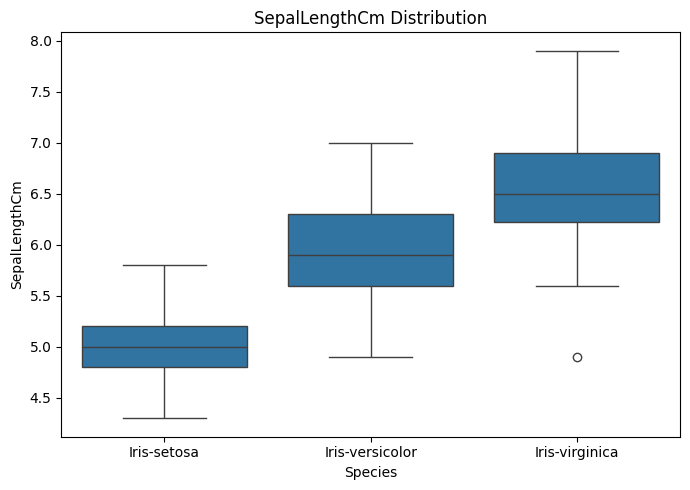

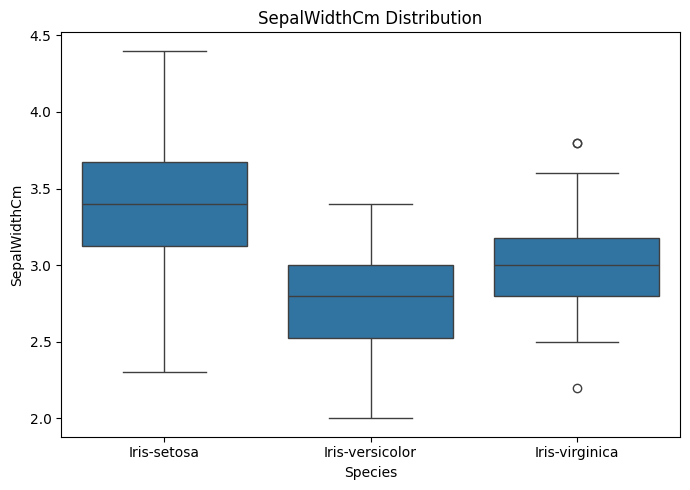

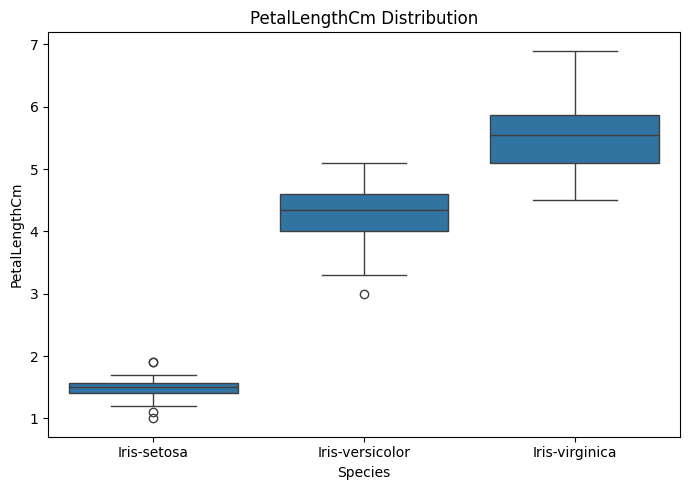

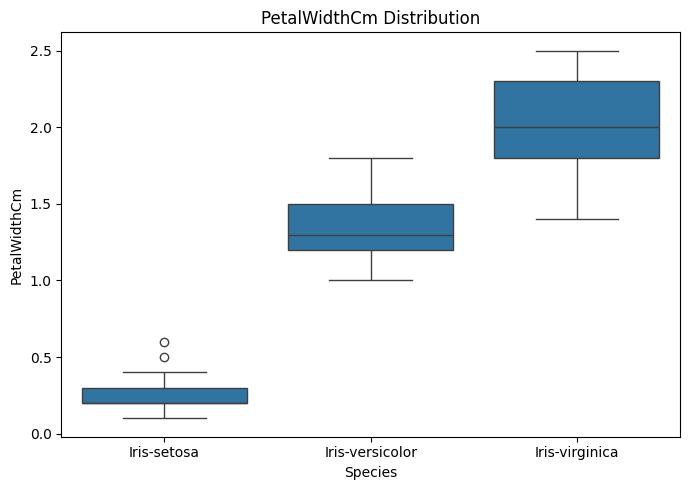

In [ ]:
# BOXPLOTS


print("Generating Boxplots...")

features = df.columns[:-1]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x="Species",
        y=feature,
        data=df
    )

    plt.title(f"{feature} Distribution")

    plt.tight_layout()

    plt.savefig(
        f"outputs/{feature}_boxplot.png",
        dpi=300
    )



Generating Correlation Heatmap...


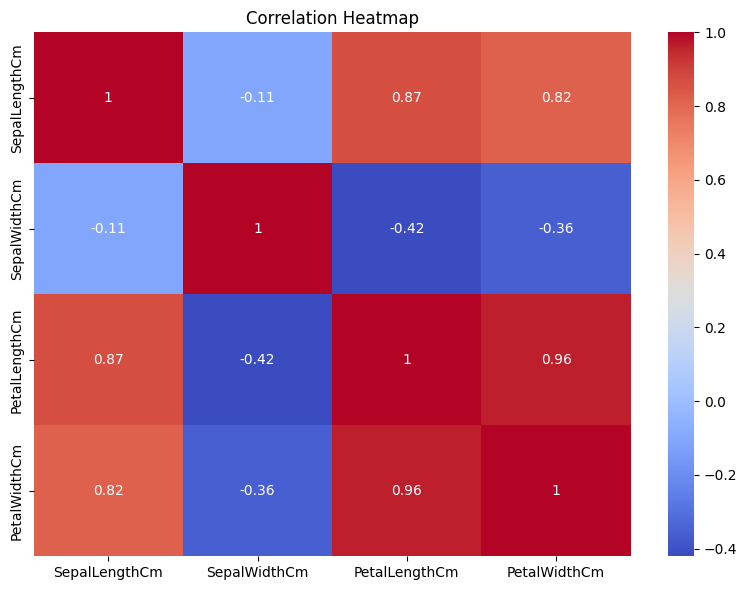

In [ ]:
# CORRELATION HEATMAP


print("Generating Correlation Heatmap...")

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("Species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "outputs/correlation_heatmap.png",
    dpi=300
)



Generating Pairplot...


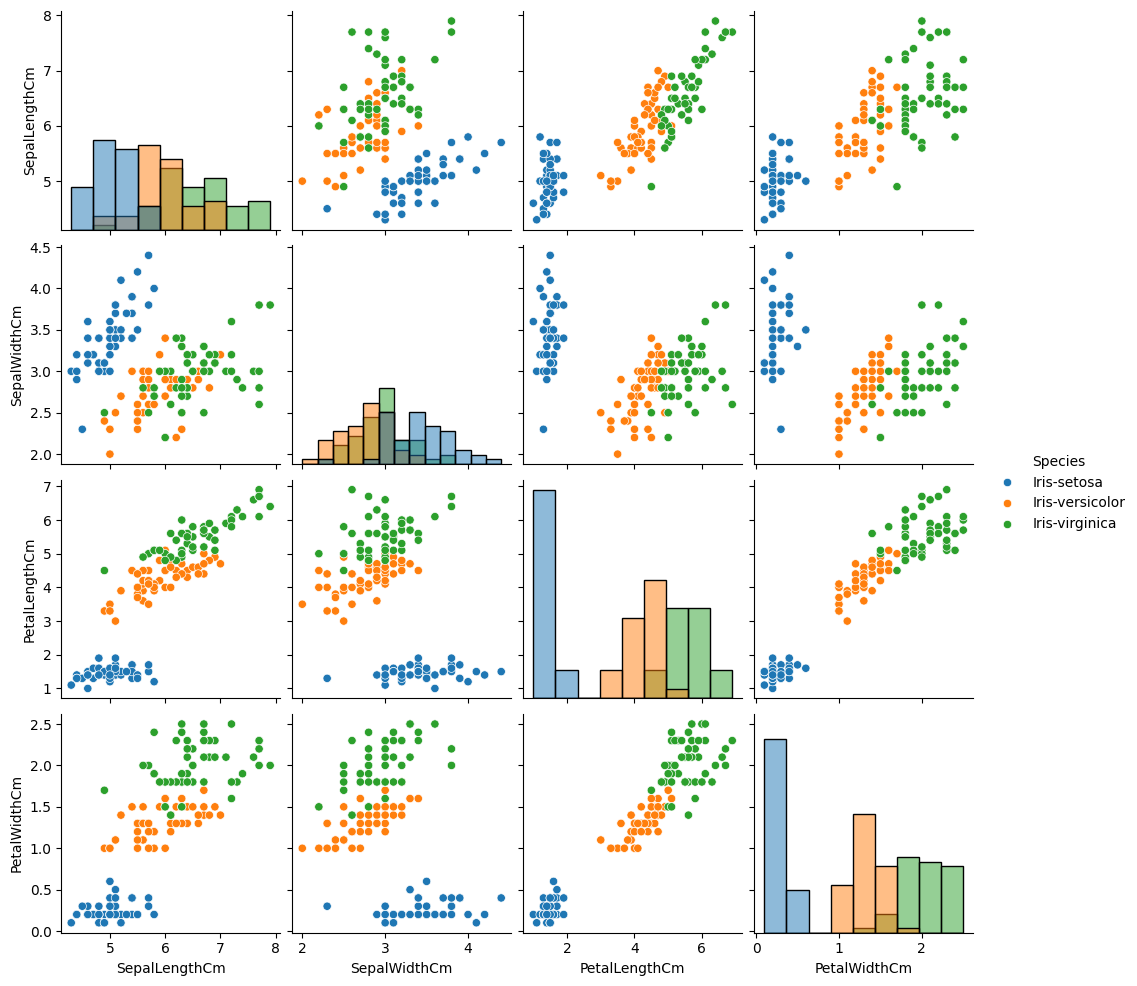

In [ ]:
# PAIRPLOT


print("Generating Pairplot...")

sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.savefig(
    "outputs/pairplot.png",
    dpi=300
)



In [ ]:

# MODEL TRAINING

print("TRAINING MACHINE LEARNING MODELS")


models = {

    "Logistic Regression":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500))
    ]),

    "KNN":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Support Vector Machine":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),

    "Decision Tree":
    Pipeline([
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest":
    Pipeline([
        ("model", RandomForestClassifier(random_state=42))
    ])

}

results = []

trained_models = {}


# TRAIN ALL MODELS

for name, pipeline in models.items():

    print(f"\nTraining {name}...")

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    cv_score = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    trained_models[name] = pipeline

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "CV Mean": cv_score.mean(),

        "CV Std": cv_score.std()

    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"CV Mean  : {cv_score.mean():.4f}")


# MODEL COMPARISON

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("MODEL COMPARISON")

print(results_df)

results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)


# MODEL COMPARISON GRAPH

plt.figure(figsize=(10,6))

sns.barplot(

    x="Accuracy",

    y="Model",

    data=results_df,

    palette="viridis"

)

plt.xlim(0.8,1.02)

plt.title("Model Accuracy Comparison")

plt.tight_layout()

plt.savefig(
    "outputs/model_accuracy.png",
    dpi=300
)

plt.close()


# BEST MODEL

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\nBest Model :", best_model_name)

# GRID SEARCH FOR RANDOM FOREST

print("\n")
print("GRID SEARCH : RANDOM FOREST")


rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {

    "model__n_estimators":[50,100,150,200],

    "model__max_depth":[None,5,10,15],

    "model__min_samples_split":[2,5,10]

}

grid_search = GridSearchCV(

    rf_pipeline,

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

print("\nBest Parameters")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy")

print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

rf_predictions = best_rf.predict(X_test)

rf_accuracy = accuracy_score(

    y_test,

    rf_predictions

)

print("\nOptimized Random Forest Accuracy")

print(rf_accuracy)

# Replace best model if GridSearch improves accuracy

if rf_accuracy > results_df.iloc[0]["Accuracy"]:


    print("\nGridSearch Random Forest selected as Best Model.")

    best_model = best_rf

    best_model_name = "Optimized Random Forest"

else:

    print("\nExisting Best Model retained.")

print("\nModel training completed successfully.")

TRAINING MACHINE LEARNING MODELS

Training Logistic Regression...
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333
CV Mean  : 0.9600

Training KNN...
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327
CV Mean  : 0.9600

Training Support Vector Machine...
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1 Score : 0.9666
CV Mean  : 0.9667

Training Decision Tree...
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333
CV Mean  : 0.9533

Training Random Forest...
Accuracy : 0.9000
Precision: 0.9024
Recall   : 0.9000
F1 Score : 0.8997
CV Mean  : 0.9667


MODEL COMPARISON
                    Model  Accuracy  Precision    Recall  F1 Score   CV Mean  \
2  Support Vector Machine  0.966667   0.969697  0.966667  0.966583  0.966667   
0     Logistic Regression  0.933333   0.933333  0.933333  0.933333  0.960000   
1                     KNN  0.933333   0.944444  0.933333  0.932660  0.960000   
3           Decision Tree  0.933333   